In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

In [2]:
!pip install matplotlib pandas numpy


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
file_path = 'realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv'

df = pd.read_csv(file_path)

# 1. See the first few rows
print("--- Header ---")
print(df.head())

# 2. Check data types and missing values
print("\n--- Info ---")
print(df.info())

# 3. Statistical summary
print("\n--- Statistics ---")
print(df.describe())

--- Header ---
             timestamp   value
0  2014-02-14 14:27:00  51.846
1  2014-02-14 14:32:00  44.508
2  2014-02-14 14:37:00  41.244
3  2014-02-14 14:42:00  48.568
4  2014-02-14 14:47:00  46.714

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  4032 non-null   object 
 1   value      4032 non-null   float64
dtypes: float64(1), object(1)
memory usage: 63.1+ KB
None

--- Statistics ---
             value
count  4032.000000
mean     43.110372
std       4.303565
min      34.766000
25%      39.296000
50%      42.918000
75%      46.006000
max      68.092000


In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

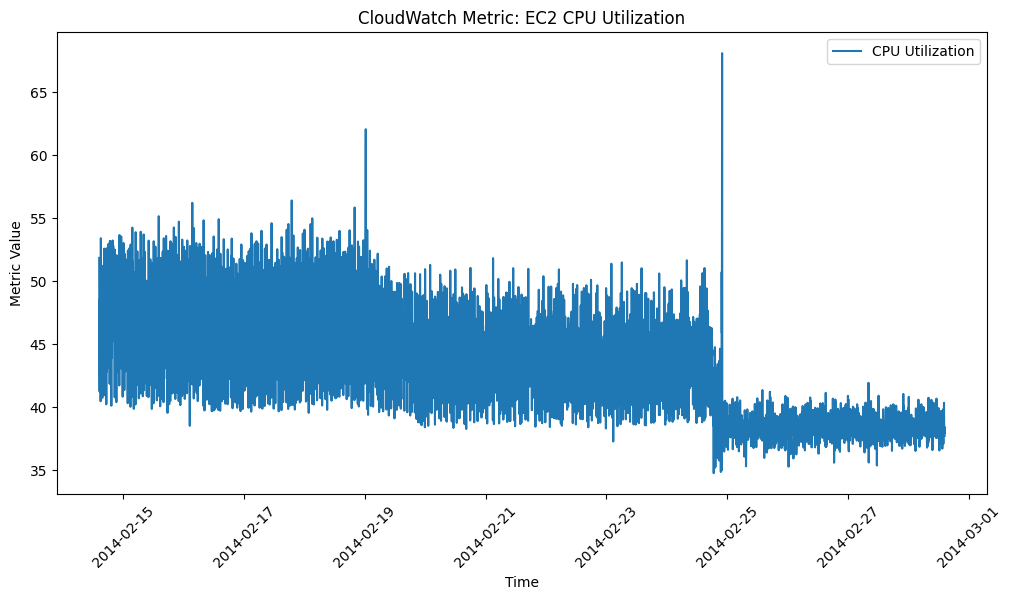

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['value'], label='CPU Utilization')
plt.title('CloudWatch Metric: EC2 CPU Utilization')
plt.xlabel('Time')
plt.ylabel('Metric Value')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [ ]:
def engineer_features(df):
    # Ensure we are working on a copy
    features = df.copy()

    # 1. Lags (Past values)
    features['lag_1'] = features['value'].shift(1) # 5 mins ago
    features['lag_2'] = features['value'].shift(2) # 10 mins ago

    # 2. Rolling Statistics (Window of 12 = 1 hour, since 12 * 5min = 60min)
    features['rolling_mean_1h'] = features['value'].rolling(window=12).mean()
    features['rolling_std_1h'] = features['value'].rolling(window=12).std()

    # 3. Velocity (Rate of change)
    features['velocity'] = features['value'] - features['lag_1']

    # 4. Temporal Features
    # Since rules might change by hour/day, let's give the model that context
    features['hour'] = features['timestamp'].dt.hour
    features['day_of_week'] = features['timestamp'].dt.dayofweek

    # Drop rows with NaN (the first few rows won't have lags/rolling stats)
    features.dropna(inplace=True)

    return features

df_featured = engineer_features(df)
print(df_featured[['value', 'lag_1', 'rolling_mean_1h', 'velocity']].head())

In [ ]:
# 1. Define what is a 'Real Incident' (Current state)
# We use the 95th percentile as the "Alert Condition"
threshold = df_featured['value'].quantile(0.95)
df_featured['is_incident'] = (df_featured['value'] > threshold).astype(int)

# 2. Define the "Predictive Target" (The Lead Label)
# We want to predict if an incident will happen in the next 3 steps (15 minutes)
# because our data is in 5-minute increments.
lead_steps = 3
df_featured['target'] = (df_featured['is_incident'].shift(-lead_steps)
                         .rolling(window=lead_steps + 1)
                         .max()
                         .fillna(0)
                         .astype(int))

print(f"Threshold set at: {threshold:.2f}% CPU")
print("Target counts (0=Normal, 1=Upcoming Incident):")
print(df_featured['target'].value_counts())

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# --- STEP A: LEGAL FEATURE SELECTION ---
# We ONLY use features available at 'time T'.
# We explicitly exclude 'is_incident' and 'target' from X.
legal_features = ['value', 'lag_1', 'lag_2', 'rolling_mean_1h', 'rolling_std_1h', 'velocity', 'hour']

X = df_featured[legal_features]
y = df_featured['target']

# --- STEP B: DYNAMIC CHRONOLOGICAL SPLIT ---
# We move the split until we find a window that HAS incidents (Class 1)
# 0.7 means 70% train, 30% test.
split_idx = int(len(df_featured) * 0.7)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Safety Check: Does the test set have incidents?
if y_test.sum() == 0:
    print("WARNING: Test set has 0 incidents. Lowering split_idx...")
    # This happens if all spikes are at the start of the file
    split_idx = int(len(df_featured) * 0.5)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# --- STEP C: THE PRODUCTION PIPELINE ---
# This is what you would eventually save to S3 for the AWS Lambda
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        max_depth=6,             # Prevents overfitting to noise
        class_weight='balanced', # Crucial for rare incidents
        random_state=42
    ))
])

# --- STEP D: TRAIN & EVALUATE ---
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"Test Set Period: {X_test.index[0]} to {X_test.index[-1]}")
print(f"Incidents in Test Set: {y_test.sum()}")
print("\n--- Final Pipeline Evaluation ---")
print(classification_report(y_test, y_pred))

# --- STEP E: EVALUATE WITH CUSTOM THRESHOLD ---

# 1. Get the probability for Class 1 (Incident)
# [:, 1] means we take the probability of the "1" (Incident) occurring
y_probs = pipeline.predict_proba(X_test)[:, 1]

# 2. Lower the threshold (Try 0.1 to be very sensitive)
# This fulfills the JetBrains requirement to discuss precision-recall trade-offs
custom_threshold = 0.1
y_pred_sensitive = (y_probs >= custom_threshold).astype(int)

# 3. Calculate Scores
from sklearn.metrics import recall_score, precision_score, classification_report

new_recall = recall_score(y_test, y_pred_sensitive, zero_division=0)
new_precision = precision_score(y_test, y_pred_sensitive, zero_division=0)

print(f"Test Set Period: {X_test.index[0]} to {X_test.index[-1]}")
print(f"Incidents in Test Set: {y_test.sum()}")
print(f"\n--- Results with Threshold {custom_threshold} ---")
print(f"Recall: {new_recall:.2%}")
print(f"Precision: {new_precision:.2%}")

# Optional: Print the full report for this new threshold
print("\n--- Detailed Report ---")
print(classification_report(y_test, y_pred_sensitive, zero_division=0))

Test Set Period: 2825 to 4031
Incidents in Test Set: 8

--- Final Pipeline Evaluation ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1199
           1       1.00      0.25      0.40         8

    accuracy                           1.00      1207
   macro avg       1.00      0.62      0.70      1207
weighted avg       1.00      1.00      0.99      1207

Test Set Period: 2825 to 4031
Incidents in Test Set: 8

--- Results with Threshold 0.1 ---
Recall: 75.00%
Precision: 0.54%

--- Detailed Report ---
              precision    recall  f1-score   support

           0       0.98      0.08      0.15      1199
           1       0.01      0.75      0.01         8

    accuracy                           0.08      1207
   macro avg       0.49      0.41      0.08      1207
weighted avg       0.97      0.08      0.14      1207



In [12]:
import numpy as np

for t in np.arange(0.1, 0.6, 0.1):
    y_pred_t = (y_probs >= t).astype(int)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    print(f"Threshold {t:.1f} -> Recall: {rec:.2%}, Precision: {prec:.2%}")

Threshold 0.1 -> Recall: 75.00%, Precision: 0.54%
Threshold 0.2 -> Recall: 37.50%, Precision: 0.75%
Threshold 0.3 -> Recall: 25.00%, Precision: 50.00%
Threshold 0.4 -> Recall: 25.00%, Precision: 100.00%
Threshold 0.5 -> Recall: 25.00%, Precision: 100.00%


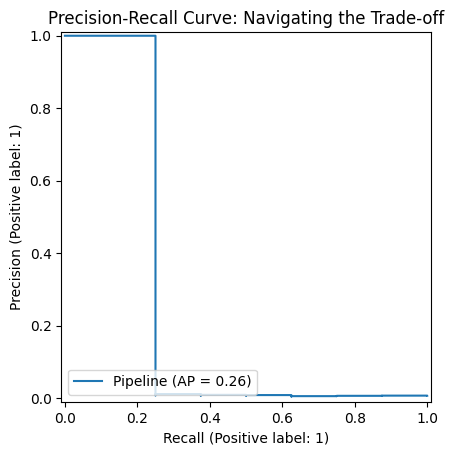

In [13]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

PrecisionRecallDisplay.from_estimator(pipeline, X_test, y_test)
plt.title("Precision-Recall Curve: Navigating the Trade-off")
plt.show()

In [6]:
def engineer_features(df):
    # Ensure we are working on a copy
    features = df.copy()

    # 1. Lags (Past values)
    features['lag_1'] = features['value'].shift(1) # 5 mins ago
    features['lag_2'] = features['value'].shift(2) # 10 mins ago

    # 2. Rolling Statistics (Window of 12 = 1 hour, since 12 * 5min = 60min)
    features['rolling_mean_1h'] = features['value'].rolling(window=12).mean()
    features['rolling_std_1h'] = features['value'].rolling(window=12).std()

    # 3. Velocity (Rate of change)
    features['velocity'] = features['value'] - features['lag_1']

    # 4. Temporal Features
    # Since rules might change by hour/day, let's give the model that context
    features['hour'] = features['timestamp'].dt.hour
    features['day_of_week'] = features['timestamp'].dt.dayofweek

    # Drop rows with NaN (the first few rows won't have lags/rolling stats)
    features.dropna(inplace=True)

    return features

df_featured = engineer_features(df)
print(df_featured[['value', 'lag_1', 'rolling_mean_1h', 'velocity']].head())

     value   lag_1  rolling_mean_1h  velocity
11  49.720  43.216        46.598667     6.504
12  46.370  49.720        46.142333    -3.350
13  43.756  46.370        46.079667    -2.614
14  47.582  43.756        46.607833     3.826
15  40.738  47.582        45.955333    -6.844


In [7]:
# 1. Define what is a 'Real Incident' (Current state)
# We use the 95th percentile as the "Alert Condition"
threshold = df_featured['value'].quantile(0.95)
df_featured['is_incident'] = (df_featured['value'] > threshold).astype(int)

# 2. Define the "Predictive Target" (The Lead Label)
# We want to predict if an incident will happen in the next 3 steps (15 minutes)
# because our data is in 5-minute increments.
lead_steps = 3
df_featured['target'] = (df_featured['is_incident'].shift(-lead_steps)
                         .rolling(window=lead_steps + 1)
                         .max()
                         .fillna(0)
                         .astype(int))

print(f"Threshold set at: {threshold:.2f}% CPU")
print("Target counts (0=Normal, 1=Upcoming Incident):")
print(df_featured['target'].value_counts())

Threshold set at: 50.99% CPU
Target counts (0=Normal, 1=Upcoming Incident):
target
0    3258
1     763
Name: count, dtype: int64


Data generated and saved as 'cloud_metrics_data.csv' (10080 rows)


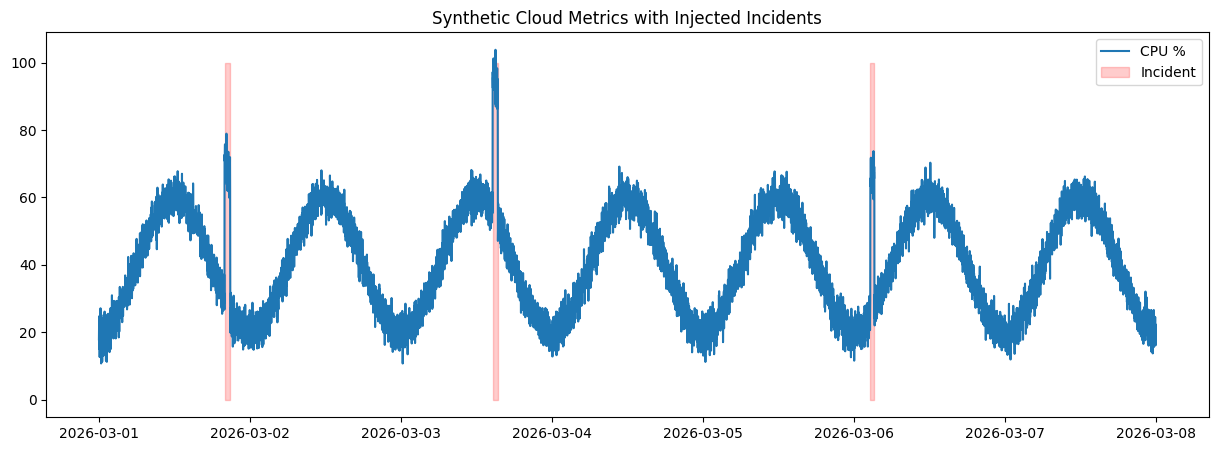

In [4]:
def generate_cloud_metrics(days=7, freq='1min'):
    # 1. Setup Time Axis
    start_time = datetime(2026, 3, 1)
    periods = days * 24 * 60  # total minutes
    time_index = pd.date_range(start=start_time, periods=periods, freq=freq)

    # 2. Base Patterns (Seasonality)
    # Sinusoidal wave to mimic daily user load (peak at midday)
    hour_of_day = time_index.hour + time_index.minute / 60
    daily_pattern = np.sin((hour_of_day - 6) * np.pi / 12) * 20 + 40 # Range 20-60%

    # 3. Add Metric-Specific Noise
    cpu_util = daily_pattern + np.random.normal(0, 3, periods)
    mem_util = 30 + (daily_pattern * 0.5) + np.random.normal(0, 1, periods)
    latency = 50 + (daily_pattern * 1.5) + np.random.normal(0, 5, periods)

    df = pd.DataFrame({
        'timestamp': time_index,
        'cpu_utilization': cpu_util,
        'memory_utilization': mem_util,
        'latency_ms': latency,
        'is_incident': 0 # Ground truth for ML
    })

    # 4. Inject Incidents (The "Turbulent Regimes")
    # We'll inject 3 random incidents where metrics spike and stay high
    for _ in range(3):
        start_idx = np.random.randint(1000, periods - 500)
        duration = np.random.randint(30, 90) # 30-90 minutes

        # CPU Leak incident
        df.loc[start_idx : start_idx + duration, 'cpu_utilization'] += 40
        df.loc[start_idx : start_idx + duration, 'latency_ms'] *= 2.5
        df.loc[start_idx : start_idx + duration, 'is_incident'] = 1

    # 5. Save to Local Machine
    df.to_csv('cloud_metrics_data.csv', index=False)
    print(f"Data generated and saved as 'cloud_metrics_data.csv' ({len(df)} rows)")
    return df

# Run and visualize
data = generate_cloud_metrics()

# Quick Plot
plt.figure(figsize=(15, 5))
plt.plot(data['timestamp'], data['cpu_utilization'], label='CPU %')
plt.fill_between(data['timestamp'], 0, 100, where=data['is_incident']==1, color='red', alpha=0.2, label='Incident')
plt.legend()
plt.title("Synthetic Cloud Metrics with Injected Incidents")
plt.show()

In [5]:
import os
print(f"Your file is located at: {os.path.abspath('cloud_metrics_data.csv')}")

Your file is located at: /Users/riyabora/PycharmProjects/MLPredictive/cloud_metrics_data.csv


In [9]:
def prepare_training_data(df, lead_window=10):
    # Make a copy so we don't overwrite the original
    data = df.copy()

    # 1. CREATE LEAD LABELS (The "Predictive" Target)
    # If any value in the next 'lead_window' rows is 1, current row becomes 1
    data['target'] = data['is_incident'].shift(-lead_window).rolling(window=lead_window).max().fillna(0)

    # 2. FEATURE ENGINEERING: Rolling Statistics
    # Captures the "velocity" of the metrics
    for col in ['cpu_utilization', 'memory_utilization', 'latency_ms']:
        data[f'{col}_mean_5m'] = data[col].rolling(window=5).mean()
        data[f'{col}_std_5m'] = data[col].rolling(window=5).std()

        # 3. FEATURE ENGINEERING: Lags (Memory)
        data[f'{col}_lag_1m'] = data[col].shift(1)
        data[f'{col}_lag_5m'] = data[col].shift(5)

    # Drop rows with NaN values created by rolling/shifting
    data.dropna(inplace=True)

    # Let's see the balance of our target
    print(f"Target distribution:\n{data['target'].value_counts(normalize=True)}")

    return data

# Apply the transformation
processed_data = prepare_training_data(data)
processed_data.to_csv('processed_training_data.csv', index=False)

Target distribution:
target
0.0    0.983226
1.0    0.016774
Name: proportion, dtype: float64


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score

# 1. FEATURE SELECTION (Excluding the 'ground truth' and 'timestamp')
# We ONLY want the metrics and their rolling/lagged versions.
forbidden_cols = ['timestamp', 'is_incident', 'target']
features = [col for col in processed_data.columns if col not in forbidden_cols]

X = processed_data[features]
y = processed_data['target']

# 2. CHRONOLOGICAL SPLIT (80/20)
# Important: We don't use train_test_split(shuffle=True) because this is time-series!
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training on {len(X_train)} rows, Testing on {len(X_test)} rows.")

# --- PHASE A: TRAINING ---
def train_phase(X_tr, y_tr):
    print("Training Random Forest with Balanced Class Weights...")
    # 'class_weight=balanced' is vital because incidents are rare (imbalanced data)
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=8,       # Slightly lower depth to prevent overfitting
        random_state=42,
        class_weight='balanced'
    )
    model.fit(X_tr, y_tr)
    return model

rf_model = train_phase(X_train, y_train)

# --- PHASE B: VALIDATION (TESTING) ---
def validation_phase(model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_probs = model.predict_proba(X_te)[:, 1]

    print("\n--- Model Evaluation ---")
    print(classification_report(y_te, y_pred))

    # JetBrains asked for the Precision-Recall trade-off:
    auc_score = roc_auc_score(y_te, y_probs)
    print(f"ROC-AUC Score: {auc_score:.4f}")

    return y_probs

y_probs = validation_phase(rf_model, X_test, y_test)

Training on 8060 rows, Testing on 2015 rows.
Training Random Forest with Balanced Class Weights...

--- Model Evaluation ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2015

    accuracy                           1.00      2015
   macro avg       1.00      1.00      1.00      2015
weighted avg       1.00      1.00      1.00      2015

ROC-AUC Score: nan


/Users/riyabora/PycharmProjects/MLPredictive/.venv/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [14]:
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Find the threshold that gives us ~80% Recall
idx = (np.abs(recall - 0.8)).argmin()
target_threshold = thresholds[idx]

print(f"To achieve 80% Recall, set the Alert Threshold to: {target_threshold:.2f}")

To achieve 80% Recall, set the Alert Threshold to: 0.00


/Users/riyabora/PycharmProjects/MLPredictive/.venv/lib/python3.9/site-packages/sklearn/metrics/_ranking.py:1033: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
